In [3]:
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank.zip
!unzip bank.zip

--2026-03-17 23:06:30--  https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘bank.zip’

bank.zip                [  <=>               ] 565.47K  2.31MB/s    in 0.2s    

2026-03-17 23:06:30 (2.31 MB/s) - ‘bank.zip’ saved [579043]

Archive:  bank.zip
  inflating: bank-full.csv           
  inflating: bank-names.txt          
  inflating: bank.csv                


In [4]:
import os
os.listdir()


['.config',
 'bank.zip',
 'bank.csv',
 'bank-names.txt',
 'bank-full.csv',
 'sample_data']

In [5]:
import pandas as pd

df = pd.read_csv("bank-full.csv", sep=';')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [6]:
from sklearn.preprocessing import LabelEncoder

# Convert target
df['y'] = df['y'].map({'yes':1, 'no':0})

# Encode categorical features
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# Split X and y
X = df.drop('y', axis=1)
y = df['y']

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [9]:
from sklearn.metrics import mean_squared_error, r2_score

In [10]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)

print("\nWITH TUNING")

print("\nRidge Regression")
print("MSE:", mean_squared_error(y_test, ridge_pred))
print("R2:", r2_score(y_test, ridge_pred))

print("\nLasso Regression")
print("MSE:", mean_squared_error(y_test, lasso_pred))
print("R2:", r2_score(y_test, lasso_pred))


WITH TUNING

Ridge Regression
MSE: 0.08168360164840756
R2: 0.21406855091809585

Lasso Regression
MSE: 0.08637015733623764
R2: 0.16897612809872153


In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("WITHOUT TUNING - Linear Regression")
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("R2 Score:", r2_score(y_test, y_pred_lr))

WITHOUT TUNING - Linear Regression
MSE: 0.08168357096408448
R2 Score: 0.214068846152072


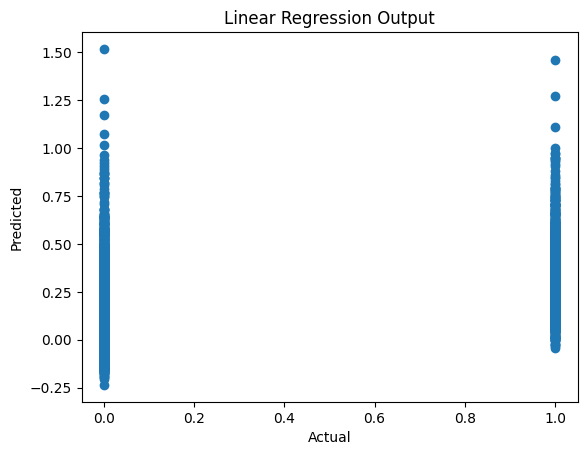

In [13]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_lr)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear Regression Output")
plt.show()

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

log = LogisticRegression(max_iter=1000)
log.fit(X_train, y_train)

y_pred_log = log.predict(X_test)

print("WITHOUT TUNING - Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))

WITHOUT TUNING - Logistic Regression
Accuracy: 0.8872014155116484

Confusion Matrix:
 [[11728   238]
 [ 1292   306]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.98      0.94     11966
           1       0.56      0.19      0.29      1598

    accuracy                           0.89     13564
   macro avg       0.73      0.59      0.61     13564
weighted avg       0.86      0.89      0.86     13564



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [15]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

grid = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
y_pred_tuned = best_model.predict(X_test)

print("WITH TUNING - Logistic Regression")
print("Best Parameters:", grid.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred_tuned))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_tuned))
print("\nClassification Report:\n", classification_report(y_test, y_pred_tuned))

WITH TUNING - Logistic Regression
Best Parameters: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
Accuracy: 0.8894131524624005

Confusion Matrix:
 [[11730   236]
 [ 1264   334]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.98      0.94     11966
           1       0.59      0.21      0.31      1598

    accuracy                           0.89     13564
   macro avg       0.74      0.59      0.62     13564
weighted avg       0.87      0.89      0.87     13564



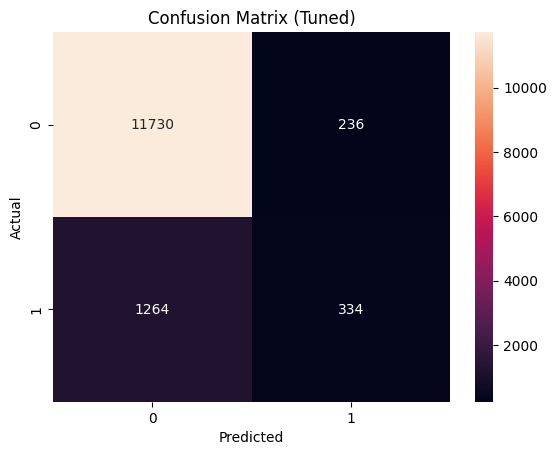

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_tuned)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix (Tuned)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [17]:
print("===== COMPARISON =====")

print("\nWITHOUT TUNING Accuracy:")
print(accuracy_score(y_test, y_pred_log))

print("\nWITH TUNING Accuracy:")
print(accuracy_score(y_test, y_pred_tuned))

===== COMPARISON =====

WITHOUT TUNING Accuracy:
0.8872014155116484

WITH TUNING Accuracy:
0.8894131524624005


In [18]:
from sklearn.metrics import f1_score

print("\nWITHOUT TUNING F1 Score:")
print(f1_score(y_test, y_pred_log))

print("\nWITH TUNING F1 Score:")
print(f1_score(y_test, y_pred_tuned))


WITHOUT TUNING F1 Score:
0.2857142857142857

WITH TUNING F1 Score:
0.3081180811808118


In [19]:
from sklearn.metrics import roc_auc_score

print("\nWITHOUT TUNING ROC-AUC:")
print(roc_auc_score(y_test, y_pred_log))

print("\nWITH TUNING ROC-AUC:")
print(roc_auc_score(y_test, y_pred_tuned))


WITHOUT TUNING ROC-AUC:
0.5857998371271795

WITH TUNING ROC-AUC:
0.5946443584314924
